In [78]:
# Load the required packages
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [79]:
# load the data
url = "https://raw.githubusercontent.com/socd06/medical-nlp/master/data/mtsamples.csv"
mtsamples = pd.read_csv(url).iloc[:, 1:]

In [71]:
mtsamples.head()

,description,medical_specialty,sample_name,transcription,keywords,medical_specialty_clean
0,A 23-year-old white female presents with comp...,Allergy / Immunology,Allergic Rhinitis,"SUBJECTIVE:, This 23-year-old white female pr...","allergy / immunology, allergic rhinitis, aller...",Allergy / Immunology
1,Consult for laparoscopic gastric bypass.,Bariatrics,Laparoscopic Gastric Bypass Consult - 2,"PAST MEDICAL HISTORY:, He has difficulty climb...","bariatrics, laparoscopic gastric bypass, weigh...",Bariatrics
2,Consult for laparoscopic gastric bypass.,Bariatrics,Laparoscopic Gastric Bypass Consult - 1,"HISTORY OF PRESENT ILLNESS: , I have seen ABC ...","bariatrics, laparoscopic gastric bypass, heart...",Bariatrics
3,2-D M-Mode. Doppler.,Cardiovascular / Pulmonary,2-D Echocardiogram - 1,"2-D M-MODE: , ,1. Left atrial enlargement wit...","cardiovascular / pulmonary, 2-d m-mode, dopple...",Cardiovascular / Pulmonary
4,2-D Echocardiogram,Cardiovascular / Pulmonary,2-D Echocardiogram - 2,1. The left ventricular cavity size and wall ...,"cardiovascular / pulmonary, 2-d, doppler, echo...",Cardiovascular / Pulmonary


In [55]:
mtsamples.columns

Index(['description', 'medical_specialty', 'sample_name', 'transcription',
       'keywords'],
      dtype='str')

In [56]:
# Drop columns without a transcript
mtsamples.dropna(subset=['transcription'], inplace=True)

In [ ]:
# Remove trailing whitespaces from the medical speciality column
mtsamples['medical_specialty_clean'] = mtsamples['medical_specialty'].str.strip()

In [58]:
mtsamples['medical_specialty'].value_counts()[lambda x: x > 100]

medical_specialty
Surgery                          1088
Consult - History and Phy.        516
Cardiovascular / Pulmonary        371
Orthopedic                        355
Radiology                         273
General Medicine                  259
Gastroenterology                  224
Neurology                         223
SOAP / Chart / Progress Notes     166
Urology                           156
Obstetrics / Gynecology           155
Discharge Summary                 108
Name: count, dtype: int64

In [59]:
# Explore the medical speciality categories.
medical_specialty_10 = mtsamples['medical_specialty_clean'].value_counts()[:10]
medical_specialty_20 = mtsamples['medical_specialty_clean'].value_counts()[10:20]
medical_specialty_30 = mtsamples['medical_specialty_clean'].value_counts()[20:30]
medical_specialty_40 = mtsamples['medical_specialty_clean'].value_counts()[30:40]

In [60]:
medical_specialty_10

medical_specialty_clean
Surgery                          1088
Consult - History and Phy.        516
Cardiovascular / Pulmonary        371
Orthopedic                        355
Radiology                         273
General Medicine                  259
Gastroenterology                  224
Neurology                         223
SOAP / Chart / Progress Notes     166
Urology                           156
Name: count, dtype: int64

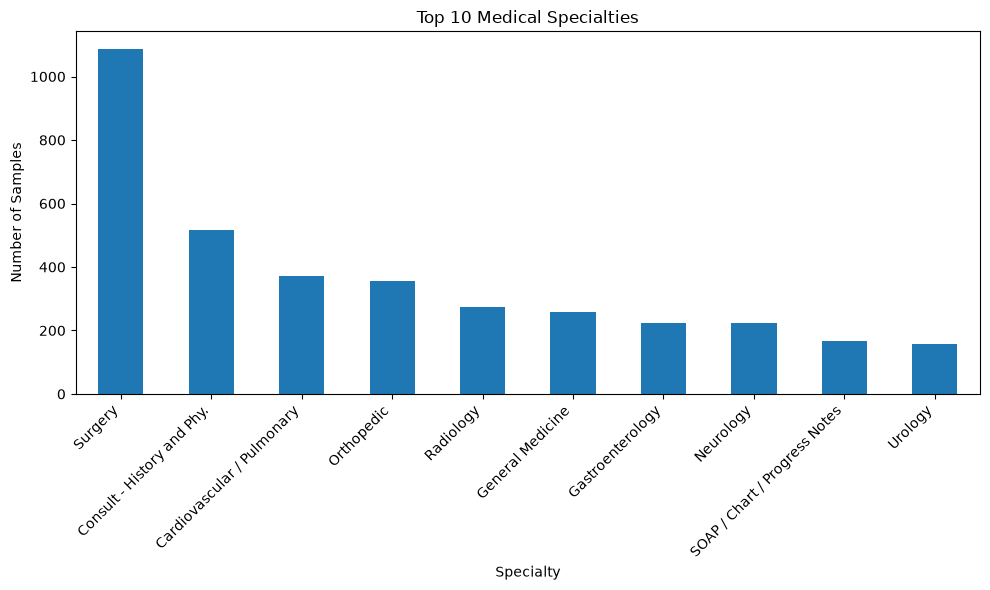

In [61]:
# Plot the medical specialties for visualisation
medical_specialty_10.plot(kind='bar', figsize=(10,6))
plt.title('Top 10 Medical Specialties')
plt.xlabel('Specialty')
plt.ylabel('Number of Samples')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

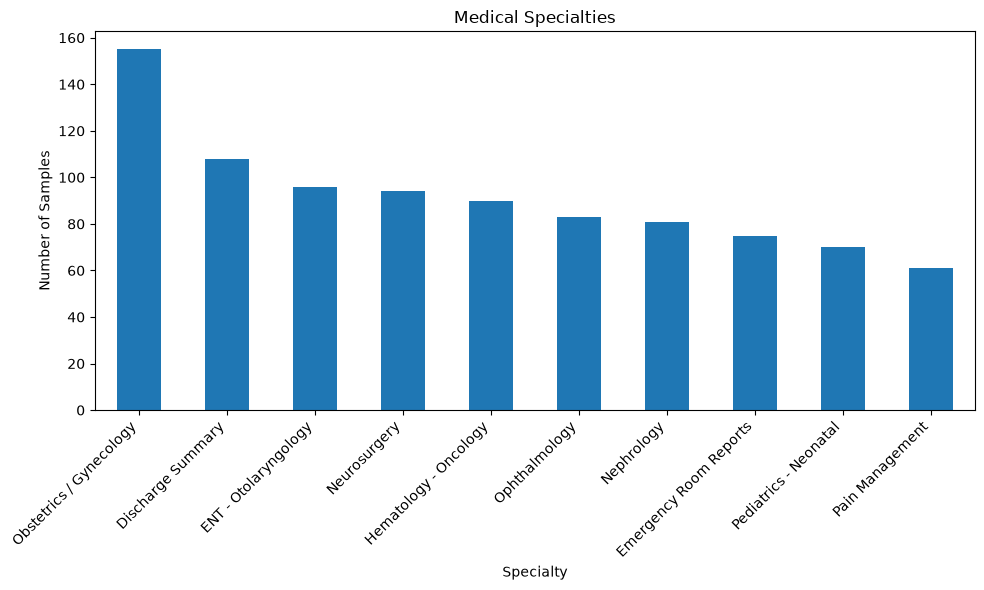

In [62]:
medical_specialty_20.plot(kind='bar', figsize=(10,6))
plt.title('Medical Specialties')
plt.xlabel('Specialty')
plt.ylabel('Number of Samples')
plt.xticks(rotation=45, ha='right')  
plt.tight_layout()
plt.show()

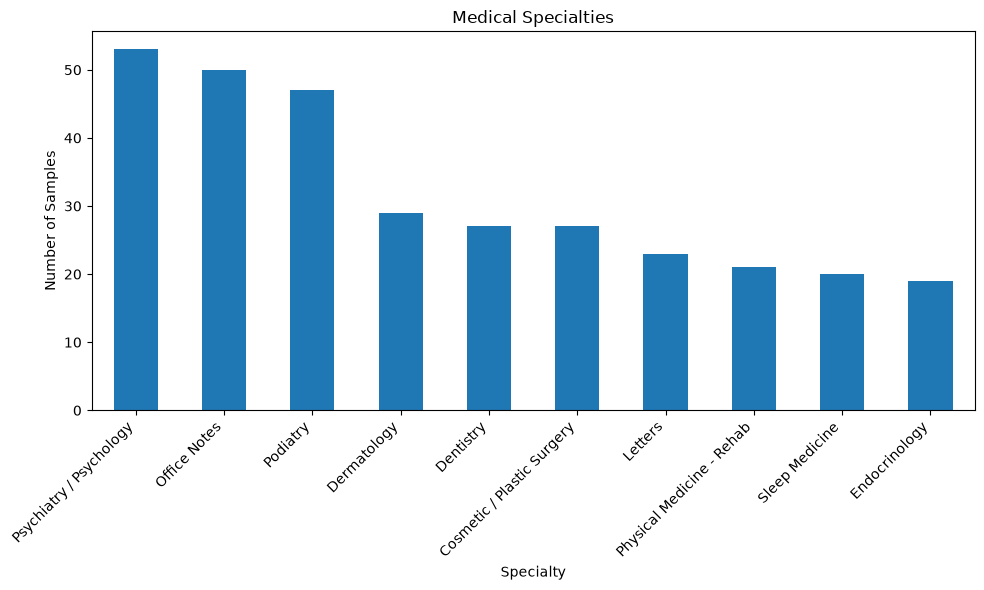

In [63]:
medical_specialty_30.plot(kind='bar', figsize=(10,6))
plt.title('Medical Specialties')
plt.xlabel('Specialty')
plt.ylabel('Number of Samples')
plt.xticks(rotation=45, ha='right')  # rotate labels for readability
plt.tight_layout()
plt.show()

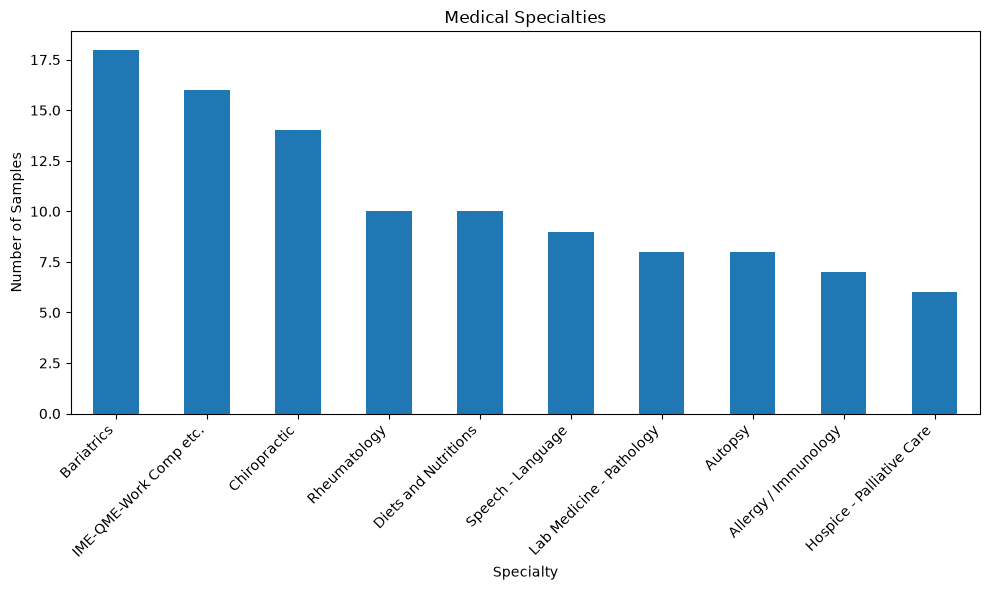

In [64]:
medical_specialty_40.plot(kind='bar', figsize=(10,6))
plt.title('Medical Specialties')
plt.xlabel('Specialty')
plt.ylabel('Number of Samples')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [73]:
mtsamples['medical_specialty'].value_counts()
mtsamples[mtsamples['medical_specialty_clean'] == 'Surgery']['transcription'].iloc[0]

'PREOPERATIVE DIAGNOSES:,1.  Hallux rigidus, left foot.,2.  Elevated first metatarsal, left foot.,POSTOPERATIVE DIAGNOSES:,1.  Hallux rigidus, left foot.,2.  Elevated first metatarsal, left foot.,PROCEDURE PERFORMED:,1.  Austin/Youngswick bunionectomy with Biopro implant.,2.  Screw fixation, left foot.,HISTORY: , This 51-year-old male presents to ABCD General Hospital with the above chief complaint.  The patient states that he has had degenerative joint disease in his left first MPJ for many years that has been progressively getting worse and more painful over time.  The patient desires surgical treatment.,PROCEDURE IN DETAIL: , An IV was instituted by the Department of Anesthesia in the preoperative holding area.  The patient was transported from the operating room and placed on the operating room table in the supine position with the safety belt across his lap.  Copious amount of Webril was placed around the left ankle followed by a blood pressure cuff.  After adequate sedation by th

In [66]:
soap_values = mtsamples[mtsamples['medical_specialty'].str.contains('SOAP', na=False)]['medical_specialty'].unique()
print(soap_values)

<StringArray>
[' SOAP / Chart / Progress Notes']
Length: 1, dtype: str
